In [12]:
import pulser
from pulse_counter_diabatic.counter_diabatic import CounterDiabaticPulse
import torch
import emu_sv

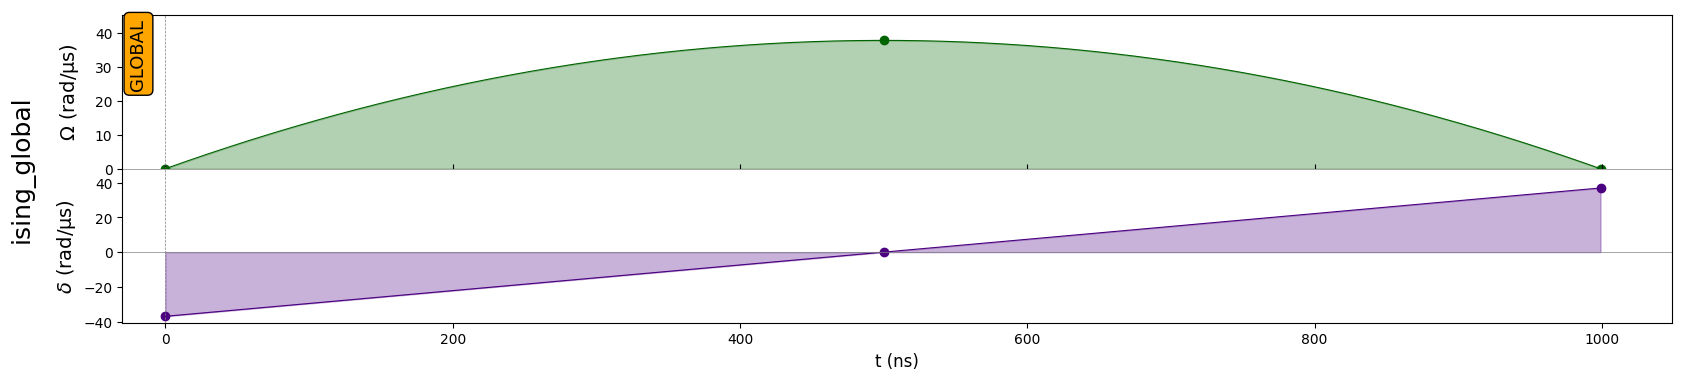

In [13]:
## pulser sequence

om_max_rabi = 1 * torch.pi * 4.0
num_atoms = 9

reg = pulser.Register.rectangle(1, num_atoms, prefix="q",spacing=7.0)

T = 1000
delta_0 = -37
delta_f = 37
adiabatic_pulse = pulser.Pulse(
    pulser.InterpolatedWaveform(T, [1e-9, 3*om_max_rabi, 1e-9]),
    pulser.InterpolatedWaveform(T, [delta_0, 0, delta_f]),
    0,
)
seq = pulser.Sequence(reg, pulser.MockDevice)
seq.declare_channel("ising_global", "rydberg_global")
seq.add(adiabatic_pulse, "ising_global")
seq.draw()

In [14]:
dt = 10
eval_times = [1.0]
mps_config = emu_sv.SVConfig(
        dt=dt,
        observables=[
            emu_sv.Occupation(evaluation_times=eval_times),
            emu_sv.BitStrings(evaluation_times=eval_times, num_shots=1000),
            #emu_mps.Energy(evaluation_times=eval_times),
            #emu_mps.EnergyVariance(evaluation_times=eval_times),
            #emu_mps.EnergySecondMoment(evaluation_times=eval_times),
            #emu_mps.CorrelationMatrix(evaluation_times=eval_times),
            emu_sv.StateResult(evaluation_times=eval_times),
            #emu_mps.Fidelity(evaluation_times=eval_times, state=fidelity_state, tag_suffix="1"),
        ],
        #noise_model=noise_model,
        #interaction_cutoff=interaction_cutoff,
        #optimize_qubit_ordering=optimize_qubit_ordering,
        #solver=solver,
    log_level=100)

backend = emu_sv.SVBackend(seq, config=mps_config)

result = backend.run()

In [15]:
ocupation = result.occupation[-1]
print(ocupation)
bitstrings = result.bitstrings[-1]
print(bitstrings)

tensor([0.8810, 0.1411, 0.7262, 0.2807, 0.6542, 0.2807, 0.7262, 0.1411, 0.8810],
       dtype=torch.float64)
Counter({'101010101': 642, '100101001': 40, '100101010': 33, '010101001': 32, '101001001': 28, '101001010': 27, '010101010': 24, '100100101': 24, '010100101': 16, '101000101': 11, '110101010': 11, '100101101': 9, '101101001': 9, '100101011': 8, '101001101': 7, '101101010': 6, '010101011': 6, '100110101': 6, '101100101': 5, '010101101': 5, '101010010': 5, '110100101': 5, '110101001': 4, '101001011': 3, '010010101': 3, '110101101': 3, '101011010': 2, '100010101': 2, '101010011': 2, '101011001': 2, '010100100': 1, '000101011': 1, '010010100': 1, '010110011': 1, '010101000': 1, '100010010': 1, '010010011': 1, '001010001': 1, '101101101': 1, '001100010': 1, '000101100': 1, '000101010': 1, '011010010': 1, '110101011': 1, '010001010': 1, '100101100': 1, '101010110': 1, '010110101': 1, '101101011': 1, '100011010': 1})


# Improving the pulse

In [ ]:
cd_seq = CounterDiabaticPulse(seq,mps_config)
solution = cd_seq.solver(nruns=500)

/home/anton/code/work/github/emulators/emu_sv/sv_config.py:83: UserWarning: 'SVConfig' was initialized without any observables. The corresponding emulation results will be empty.
  super().__init__(


step    0  loss = 1.244933e+04
step    1  loss = 1.190688e+04
step    2  loss = 1.156641e+04
step    3  loss = 1.118536e+04
step    4  loss = 1.071245e+04
step    5  loss = 1.021078e+04
step    6  loss = 9.742767e+03
step    7  loss = 9.388791e+03
step    8  loss = 9.220579e+03
step    9  loss = 9.152562e+03
step   10  loss = 9.061736e+03
step   11  loss = 8.932491e+03
step   12  loss = 8.826682e+03
step   13  loss = 8.794617e+03
step   14  loss = 8.791920e+03
step   15  loss = 8.743695e+03
step   16  loss = 8.625068e+03
step   17  loss = 8.448651e+03
step   18  loss = 8.252115e+03
step   19  loss = 8.085885e+03
step   20  loss = 7.988204e+03
step   21  loss = 7.942233e+03
step   22  loss = 7.902451e+03
step   23  loss = 7.848087e+03
step   24  loss = 7.775595e+03
step   25  loss = 7.690663e+03
step   26  loss = 7.597646e+03
step   27  loss = 7.500884e+03
step   28  loss = 7.404045e+03
step   29  loss = 7.310469e+03
step   30  loss = 7.232611e+03
step   31  loss = 7.174989e+03
step   3

In [17]:
from dataclasses import replace
detached_solution = replace(solution, omega = solution.omega.detach(), delta = solution.delta.detach(), phi = solution.phi.detach())
eval_times = [1.0]
config_cd = emu_sv.SVConfig(
      dt=dt,
      observables=[
          emu_sv.Occupation(evaluation_times=eval_times),
          emu_sv.BitStrings(evaluation_times=eval_times, num_shots=1000),
          emu_sv.StateResult(evaluation_times=eval_times),
      ],
      log_level=100,
  )

result_cd = emu_sv.SVBackend._run_from_sequence_data(detached_solution, config_cd)

print("Original")
print(result.bitstrings[-1])

print("CD corrected")
print(result_cd.bitstrings[-1])

Original
Counter({'101010101': 642, '100101001': 40, '100101010': 33, '010101001': 32, '101001001': 28, '101001010': 27, '010101010': 24, '100100101': 24, '010100101': 16, '101000101': 11, '110101010': 11, '100101101': 9, '101101001': 9, '100101011': 8, '101001101': 7, '101101010': 6, '010101011': 6, '100110101': 6, '101100101': 5, '010101101': 5, '101010010': 5, '110100101': 5, '110101001': 4, '101001011': 3, '010010101': 3, '110101101': 3, '101011010': 2, '100010101': 2, '101010011': 2, '101011001': 2, '010100100': 1, '000101011': 1, '010010100': 1, '010110011': 1, '010101000': 1, '100010010': 1, '010010011': 1, '001010001': 1, '101101101': 1, '001100010': 1, '000101100': 1, '000101010': 1, '011010010': 1, '110101011': 1, '010001010': 1, '100101100': 1, '101010110': 1, '010110101': 1, '101101011': 1, '100011010': 1})
CD corrected
Counter({'101010101': 737, '100101001': 60, '100100101': 30, '100101010': 21, '101000101': 20, '101001001': 19, '010101010': 13, '010101001': 11, '100101101